# Bildverarbeitung in Python
Bibliotheken für Bildverarbeitung in Python sind unter anderem Pillow und OpenCV.
Zum grundlegen Verständnis werden wir anfangs die Operationen mit ```numpy``` und ```matplotlib``` ausführen.

Hier werden relevante Bibliotheken importiert:

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

### Import und Anzeigen eines Testbildes

Für die Übungen verwenden wir das klassische Testbild **Peppers** from the [USC-SIPI Image Database](https://sipi.usc.edu/database/).

Mehr Informationen zur Repräsentation von Bildern mit Pillow inklusive der Argumente `size`, `mode`:
https://pillow.readthedocs.io/en/latest/handbook/concepts.html

Nach der Konvertierung in ein NumPy-Array, können wir das Bild als Matrix bearbeiten und mit [`plt.imshow()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) anzeigen. `Matplotlib` verarbeitet dabei unterschiedliche Datentypen: Während **Integer-Werte** standardmäßig im klassischen 8-Bit-Bereich von [0,255] interpretiert werden, müssen **Floats** auf den Bereich [0,1] normalisiert sein. Über die Argumente `vmin=0, vmax=255` lässt sich der Wertebereich starr eingrenzen, um eine automatische Skalierung zu verhindern. Das Argument `cmap='gray'` sorgt dafür, dass einkanalige Daten als echtes Graustufenbild ausgegeben werden.

Format:  PNG
Größe:  (512, 512)
Modus:  RGB
Array-Shape:  (512, 512, 3)
Datentyp:  uint8
Beispielpixel [y, x]:  [194  28  36]
Pixelwerte:
 [[[101   0   0]
  [140   0 142]
  [151   0 146]
  ...
  [192   0 158]
  [205   0 177]
  [120   0 181]]

 [[123   0   0]
  [191  96  46]
  [190  87  51]
  ...
  [154 202  85]
  [136 188  86]
  [115 192  85]]

 [[126   0   0]
  [185 102  50]
  [185  93  48]
  ...
  [144 200  91]
  [148 200  77]
  [113 195  87]]

 ...

 [[ 92   0   0]
  [127 137  47]
  [136 145  54]
  ...
  [181 213 174]
  [177 210 170]
  [189 197 129]]

 [[ 92   0   0]
  [142 124  52]
  [126 115  48]
  ...
  [175 211 163]
  [176 206 170]
  [196 165 117]]

 [[ 93   0   0]
  [119  79  36]
  [139 135  58]
  ...
  [166 199 150]
  [171 205 181]
  [198 200 171]]]


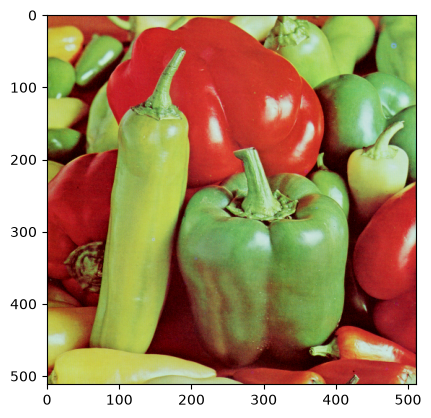

In [3]:
# Import des Bildes
img  = Image.open("peppers_4.2.07.png")

# Bildeigenschaften
print("Format: ", img.format)
print("Größe: ", img.size)
print("Modus: ", img.mode)

# Konvertierung zu NumPy-Array
img = np.asarray(img)
print("Array-Shape: ", img.shape)
print("Datentyp: ", img.dtype)
print("Beispielpixel [y, x]: ", img[100, 100])
print("Pixelwerte:\n", img)

# Anzeigen des Bildes
plt.imshow(img)

### Aufgabe Graustufen - Einfache Mittelwertbildung

Ein Graustufenbild besitzt für jedes Pixel nur **einen** Intensitätswert, während ein RGB-Bild drei Kanalwerte besitzt.

Berechnen Sie aus dem RGB-Bild ein Graustufenbild, indem Sie den Mittelwert der drei Farbkanäle entlang der Kanalachse bilden.

Tipp: Achten Sie auf die Dimensionen des Arrays: `H × W × 3` soll zu `H × W` werden.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

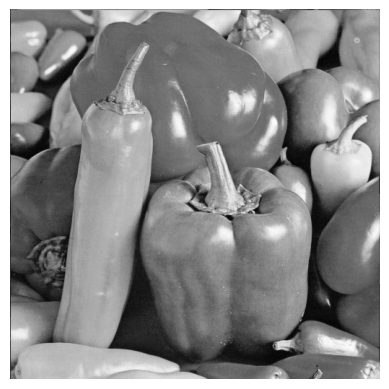

In [29]:
# Berechnung Mittelwert über die drei Farbkanäle
img_gray = np.empty((512,512))
for i in range(512):
    for j in range(512):
        for k in range(3):
            img_gray[i,j] += img[i,j,k]
# Anzeigen des Bildes
plt.imshow(img_gray, cmap="gray")
plt.axis("off")

### Aufgabe Graustufen - Gewichtete Luminanz (Y)

Die Mittelwertmethode ist einfach, berücksichtigt aber nicht die unterschiedliche spektrale Empfindlichkeit des menschlichen Sehens. Grün trägt stärker zur wahrgenommenen Helligkeit bei als Blau.

Eine häufig verwendete Näherung für die Luminanz (Maß für Helligkeit von Bildpunkten) ist daher

$Y = 0.299R + 0.587G + 0.114B$.

Berechnen Sie das Graustufenbild nun mit dieser gewichteten Summe.

**Hinweis:** Die Koeffizienten beziehen sich auf die Kanalreihenfolge RGB. Diese Gewichtung entspricht der Helligkeitskomponente (Y) des [YCbCr-Farbmodells](https://de.wikipedia.org/wiki/YCbCr-Farbmodell) (nach dem etablierten Standard ITU-R BT.601).

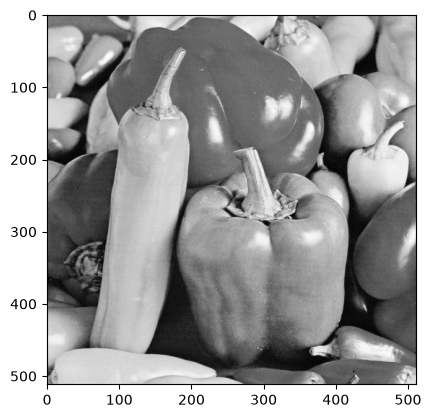

In [5]:
# Gewichtete Graustufenumwandlung
img_gray_weighted = np.empty((512,512))
for i in range(512):
    for j in range(512):
        img_gray_weighted[i,j] = 0.299*img[i,j,0] + 0.587*img[i,j,1] + 0.114*img[i,j,2] 

# Anzeigen des Bildes
plt.imshow(img_gray_weighted, cmap="gray")

Die gewichtete Luminanz berücksichtigt die unterschiedliche Empfindlichkeit des menschlichen Sehens gegenüber den drei Farbkanälen und liefert daher eine plausiblere Graustufendarstellung als die einfache Mittelwertbildung.

Auch bei `cv2.COLOR_RGB2GRAY` wird deshalb eine gewichtete Konversion verwendet.

Beim Vergleich mit der einfachen Mittelwertbildung sind Unterschiede erkennbar, die Darstellung bleibt insgesamt jedoch sehr ähnlich.

Wichtig ist außerdem, dass ein **Graustufenbild pro Pixel weiterhin genau einen Helligkeitswert** enthält, anstatt drei Farbkanäle wie ein RGB-Bild.

### Aufgabe – Graustufenumwandlung mit OpenCV

Führen Sie die Graustufenkonversion nun mit der OpenCV-Funktion cv2.cvtColor() und der Konvertierungsoption cv2.COLOR_RGB2GRAY durch. Vergleichen Sie das Ergebnis mit den vorherigen Methoden und beurteilen Sie, ob sich Unterschiede ergeben.


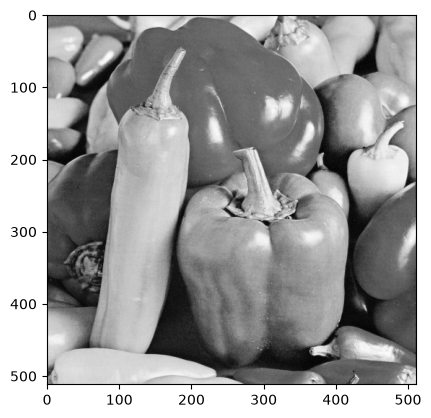

In [6]:
# Gewichtete Graustufenumwandlung
img_gray_cv = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Anzeigen des Bildes
plt.imshow(img_gray_cv, cmap="gray")

### Aufgabe Spiegelung

Spiegeln Sie `img_gray` an einer **vertikalen Achse**, sodass links und rechts vertauscht werden.

Implementieren Sie die Operation zunächst selbst und verwenden Sie **keine** fertigen Funktionen wie [`np.flip()`](https://numpy.org/doc/2.3/reference/generated/numpy.flip.html) oder [`cv2.flip()`](https://docs.opencv.org/4.x/d2/de8/group__core__array.html).

Überlegen Sie vor dem Programmieren:
- Welche Dimension entspricht der Bildhöhe?
- Welche Dimension entspricht der Bildbreite?
- Welche Pixelposition muss mit welcher Position vertauscht werden?

In [7]:
# Speichern der Bilddimensionen in den Variablen m und n
m, n = 512, 512
print("Höhe: ", m)
print("Breite: ", n)

Höhe:  512
Breite:  512


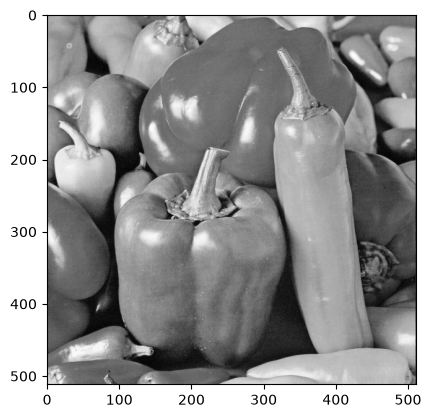

In [8]:
# Spiegelung an der vertikalen Achse
img_mir = np.empty((512,512))

for i in range(512):
    for j in range(512):
        img_mir[i,j] = img_gray[i,511-j]

# Anzeigen des Bildes
plt.imshow(img_mir, cmap="gray")

### Aufgabe Rotieren

Rotieren Sie das Bild um 90° nach links.

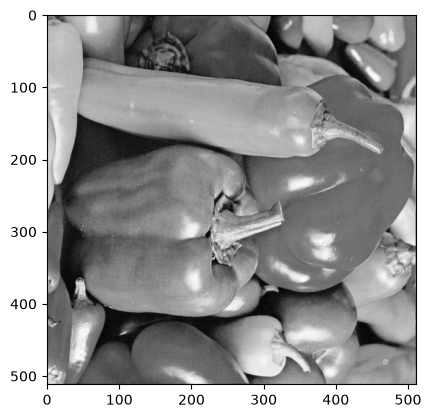

In [13]:
# Rotation um 90° nach links
img_rotl = img_gray.T[::-1]

img_rotl = np.transpose(img_gray, (1, 0))[:, ::-1]

plt.imshow(img_rotl, cmap="gray")


Rotieren Sie das Bild um 180°.

In [ ]:
# Rotation um 180°
img_rot180 = 

# Anzeigen des Bildes


Rotieren Sie das Bild um 90° nach rechts.

In [ ]:
# Rotation um 90° nach rechts
img_rot270 = 

# Anzeigen des Bildes 
plt.imshow(img_rot270, cmap="gray")

### Aufgabe Transformationen mit NumPy und OpenCV

Die oben selbst implementierten Transformationen zeigen, dass Bildoperationen letztlich **Operationen auf Array-Indizes** sind.
Für reale Anwendungen lassen sie sich auch mit fertigen
Bibliotheksfunktionen aus **NumPy** und **OpenCV** durchführen.


Für Spiegelungen stehen beispielsweise `np.flip()` und `cv2.flip()` zur Verfügung.
Für Rotationen können `np.rot90()` und `cv2.rotate()` verwendet werden.

**Dokumentation:**

- [`np.flip()`](https://numpy.org/doc/2.1/reference/generated/numpy.flip.html)
- [`cv2.flip()`](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#gaca7be533e3dac7feb70fc60635adf441)
- [`np.rot90()`](https://numpy.org/doc/stable/reference/generated/numpy.rot90.html)
- [`cv2.rotate()`](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#ga4ad01c0978b0ce64baa246811deeac24)

Setzen Sie die folgenden beiden Transformationen mithilfe der angegebenen
Funktionen um und vergleichen Sie die Ergebnisse mit Ihren eigenen Implementierungen.

Spiegeln Sie `img_gray` horizontal mit `np.flip()`.

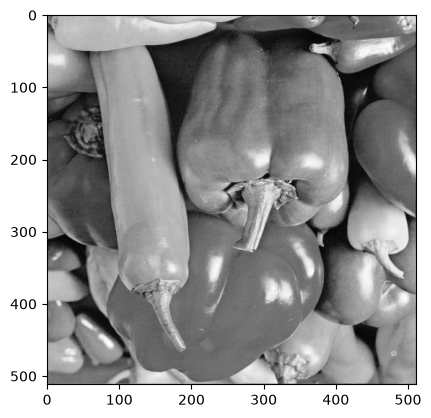

In [17]:
# Horizontale Spiegelung mit np.flip()
img_mir = img_gray[:, ::-1]
img_mir = np.flip(img_gray, axis=0)

# Anzeigen des Bildes
plt.imshow(img_mir, cmap="gray")

Rotieren Sie `img_gray` um 90° nach rechts mit `cv2.rotate()`.

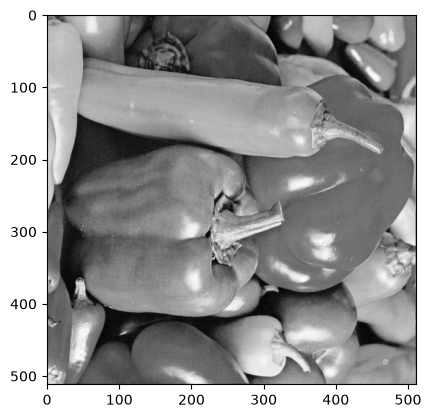

In [18]:
# Rotation um 90° nach rechts mit cv2.rotate()
img_rot270 = cv2.rotate(img_gray, cv2.ROTATE_90_CLOCKWISE)

# Anzeigen des Bildes
plt.imshow(img_rot270, cmap="gray")

## Aufgabe: Farbkanäle

Ein RGB-Bild besitzt drei Farbkanäle:

- **R**: Rot
- **G**: Grün
- **B**: Blau

Erzeugen Sie drei neue Bilder:

- ein Bild, in dem nur der **rote Kanal** aktiv ist,
- ein Bild, in dem nur der **grüne Kanal** aktiv ist,
- ein Bild, in dem nur der **blaue Kanal** aktiv ist.

Die beiden jeweils anderen Kanäle sollen mit Nullen gefüllt werden.

**Tipp:** Verwenden Sie [`np.stack()`](https://numpy.org/doc/stable/reference/generated/numpy.stack.html), um die einzelnen Kanäle wieder zu einem RGB-Bild zusammenzufügen.

Achten Sie darauf, dass die erzeugten Bilder weiterhin die Form `H × W × 3` und einen passenden Datentyp besitzen.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

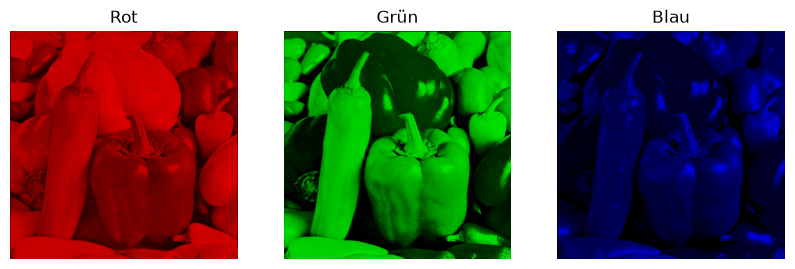

In [32]:
# Aufteilung der Farbkanäle
img_r = img[:, :, 0]
img_g = img[:, :, 1]
img_b = img[:, :, 2]

# Nullmatrix der richtigen Dimension
img_null = np.zeros((512, 512), dtype=np.uint8)

# Verknüpfen der Arrays
img_r_full = np.stack([img_r, img_null, img_null], axis=2)
img_g_full = np.stack([img_null, img_g, img_null], axis=2)
img_b_full = np.stack([img_null, img_null, img_b], axis=2)

# Anzeigen der Bilder
plt.figure(figsize=(10,3))

plt.subplot(1, 3, 1)
plt.imshow(img_r_full)
plt.title("Rot")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_g_full)
plt.title("Grün")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_b_full)
plt.title("Blau")
plt.axis("off")

## Aufgabe: HSV-Farbraum

Konvertieren Sie das RGB-Bild in den **HSV-Farbraum**.

HSV beschreibt eine Farbe mit drei Komponenten:

- **Hue (H)**: Farbton
- **Saturation (S)**: Sättigung
- **Value (V)**: Helligkeit

Verwenden Sie für die Konvertierung eine passende Funktion aus **OpenCV**.

Stellen Sie anschließend die drei HSV-Komponenten als separate Bilder dar.

Weitere Informationen zur HSV-Konvertierung finden Sie in der
[OpenCV-Dokumentation](https://docs.opencv.org/4.x/de/d25/imgproc_color_conversions.html).

**Tipp:** Für Farbraumkonvertierungen in OpenCV wird `cv2.cvtColor()` verwendet.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

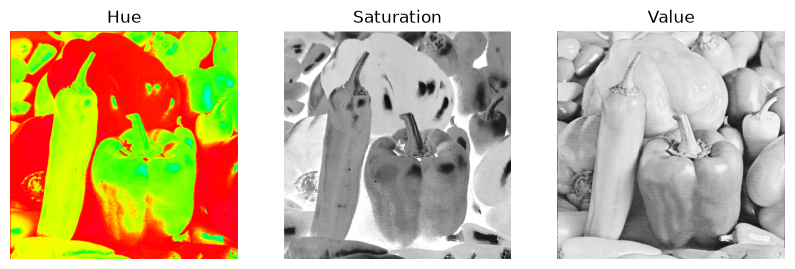

In [22]:
# Konvertierung von RGB nach HSV
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# Aufteilung der HSV-Kanäle
H = img_hsv[:, :, 0]
S = img_hsv[:, :, 1]
V = img_hsv[:, :, 2]

# Anzeigen der HSV-Kanäle
plt.figure(figsize=(10,3))

plt.subplot(1, 3, 1)
plt.title("Hue")
plt.imshow(H, cmap="hsv")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Saturation")
plt.imshow(S, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Value")
plt.imshow(V, cmap="gray")
plt.axis("off")

- **Hue** zeigt, welcher Farbton vorliegt bzw. wo er auf dem Farbspektrum liegt.

- **Saturation** zeigt, wie stark eine Farbe gesättigt ist. Hohe Werte stehen für kräftige, reine Farben, niedrige Werte für blasse Farben bis hin zu Grau.

- **Value** beschreibt die Helligkeit. Im Gegensatz zum Graustufenbild wird hier nicht der Mittelwert der RGB-Kanäle verwendet, sondern der maximale RGB-Wert.

## Aufgabe: Histogramm

Das Histogramm beschreibt die Häufigkeitsverteilung der Pixelwerte.

Erstellen Sie ein Histogramm für das Graustufenbild `img_gray`.

Das Histogramm soll für jeden möglichen Bildwert zählen, wie häufig dieser
im Bild vorkommt.

Berechnen Sie für jeden möglichen Grauwert, wie oft er im Bild vorkommt. Anschließend normieren Sie die Häufigkeiten durch die Gesamtzahl der Pixel.

**Tipp:** Eine einfache Möglichkeit ist die Verwendung von zwei verschachtelten
Schleifen über die Bildpunktkoordinaten. Der jeweilige Bildwert kann dabei
direkt als Index des Histogramms verwendet werden.

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between 'x' with shape (256,) and 'height' with shape (674,).

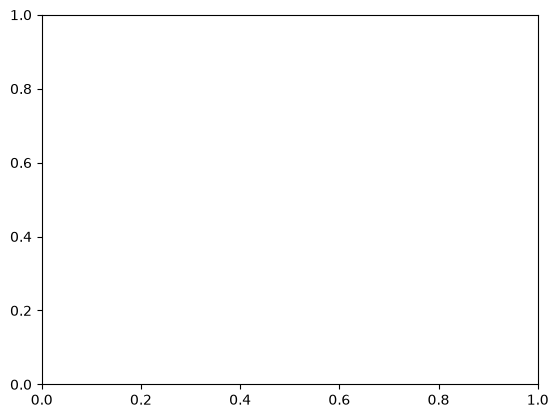

In [31]:
# Anzahl der möglichen Grauwerte bei 8 Bit Bild
greyvalues = 2**8
img_hist = img_gray.astype(int) #Konversion zu int

# Berechnung des Histogramms
hist = np.bincount(img_hist.ravel(), minlength=greyvalues)

# Normalisierung
hist = hist / hist.sum()

# Histogramm anzeigen
plt.bar(range(greyvalues), hist, width=1.0, edgecolor='black')
plt.xlabel("Grauwert")
plt.ylabel("Relative Häufigkeit")
plt.xlim(0, greyvalues-1)
plt.show()

## Aufgabe: Histogramm mit `plt.hist()`

Erstellen Sie das Histogramm des Graustufenbildes `img_gray` nun mit der
Matplotlib-Funktion `plt.hist()`.

Vergleichen Sie das Ergebnis mit dem zuvor selbst implementierten Histogramm.

**Tipp:** Verwenden Sie 256 Klassen (Bins), um die möglichen Grauwerte von
0 bis 255 abzudecken.

Weitere Informationen finden Sie in der
[Dokumentation von `plt.hist()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).

Text(0, 0.5, 'Relative Häufigkeit')

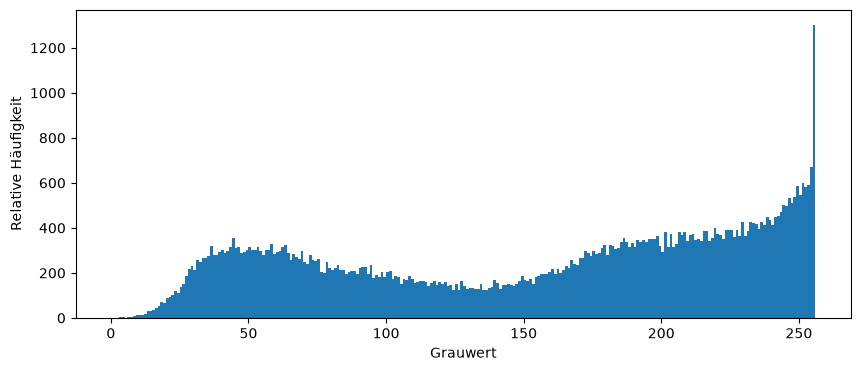

In [26]:
# Histogramm mit plt.hist()
plt.figure(figsize=(10, 4))

plt.hist(img_gray.ravel(), bins=256, range=(0, 256))

plt.xlabel("Grauwert")
plt.ylabel("Relative Häufigkeit")